In [1]:
from ugropy import unifac

import pandas as pd

In [2]:
sols = unifac.get_groups("COC(=O)CC1=CC=CC=C1", "smiles", search_multiple_solutions=True)

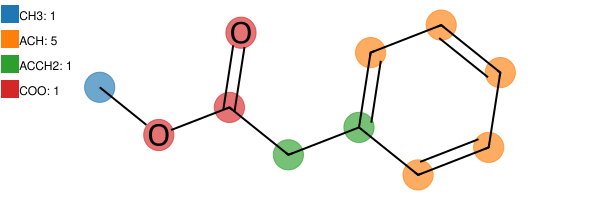

In [3]:
sols[0].draw(width=600)

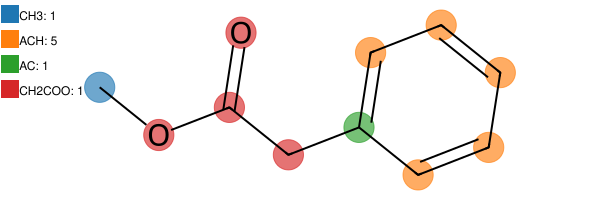

In [4]:
sols[1].draw(width=600)

In [14]:
filter = unifac.filter_polarity_contribution(sols, "Q", "polar")

filter

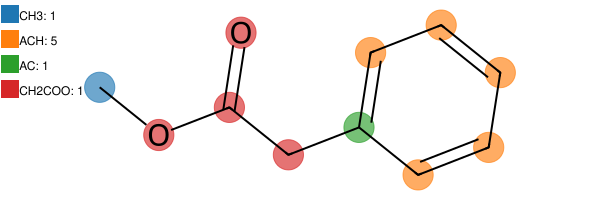

In [15]:
filter[0].draw(width=600)

In [ ]:
df = pd.read_csv("ddbst_tests.csv", index_col=1, skiprows=4)

df

,code,number,solution
smiles,,,
CC1=C(C(=CC(=C1Cl)Cl)Cl)Cl,ZOXPZFFPPKVNEA-UHFFFAOYSA-N,13870,9:1|11:1|53:4
CCC=CCC1=C(CCC1=O)C,XMLSXPIVAXONDL-UHFFFAOYSA-N,10261,1:2|2:3|19:1|70:1|6:1
C#CCCl,LJZPPWWHKPGCHS-UHFFFAOYSA-N,12221,65:1|44:1
C1=CN=CC=C1CCN,IDLHTECVNDEOIY-UHFFFAOYSA-N,83275,2:1|29:1|38:1
C[Si](C)(C)C[Si](C)(C)CCl,WBZTYASEAQTKBK-UHFFFAOYSA-N,87574,1:5|2:1|44:1|81:2
...,...,...,...
CN(C)C1=CC=CC2=C1C=CC=C2N(C)C,TYMBOHQMUQAOBA-UHFFFAOYSA-N,139088,1:2|10:4|34:2|9:6
C=CCCCCCCCCCC=C,BPHFKBMQSYYNGQ-UHFFFAOYSA-N,30874,2:9|5:2
C=CC#N.C1=CC(=CC(=C1)CN)CN,XMEXUJUMKRUUNG-UHFFFAOYSA-N,71311341,9:4|10:2|68:1|29:2


In [3]:
def get_sol_dict(solution: str):
    sol_dict = {}

    for group in solution.split("|"):
        g, o = group.split(":")
        
        group_name = unifac.subgroups_info[unifac.subgroups_info["subgroup_number"] == int(g)].index[0]

        sol_dict[group_name] = int(o)

    return sol_dict

In [ ]:
count_total = 0
count_incorrect = 0

count_sol_in_multiple = 0
count_filter_failed = 0

for smiles, row in df.iterrows():
    if "??" in row["code"]:
        # Skips solutions that take too long (to many simetryc solutions)
        # 30 molecules among all the ddataframe
        continue
    
    ddbst_sol = get_sol_dict(row["solution"])
    ugropy_sol = unifac.get_groups(smiles, "smiles")

    if ddbst_sol != ugropy_sol:
        # If first solution doesn't match, check for multiple solutions
        
        
        ugropy_sols = unifac.get_groups(smiles, "smiles", search_multiple_solutions=True)
        ugropy_sols_dicts = [sol.subgroups for sol in ugropy_sols]
        
        if ddbst_sol not in ugropy_sols_dicts:
            count_incorrect += 1
        else:
            # Check if filter choose the correct solution among multiple solutions
            count_sol_in_multiple += 1
            
        

    count += 1

27000 0 CC(C)C(C(=O)O)NC
27001 0 C1=CC=C(C=C1)CC2=CC=CC3=CC=CC=C32
27002 0 C[Si](C1=CC=CC=C1)(C2=CC=CC=C2)O
27003 0 CC(C)C1=CC2=C(C=C1)N=CC=C2
27004 0 CCCC1CCCCC1O
27005 0 C(C(Cl)(Cl)Cl)(Cl)(Cl)Cl
27006 0 C1CC2(CCC1(C2)Cl)Cl
27007 0 CCCC#CC
27008 0 CCC1=C(C(=C(C=C1)Cl)CC)N
27009 0 C1=CC=C(C=C1)C(C2=CC=C(C=C2)Cl)N
27010 0 CC1=C(C(=C(C=C1)O)N)C
27011 0 CCCCCCCCC/C=C/CCCCCCCC(=O)OC[C@H](CO)COCOCC(CO)CO
27012 0 CCCCCCCCCCCCCCCCCCCCCC
27013 0 CC1=CCCC(C1CCC(C)C=O)(C)C
27014 0 CC1=CC(=CN=C1)C
27015 0 C1=CC(=CC=C1C(F)(F)F)I
27016 0 C(CS)C(=O)NCCNC(=O)CCS
27017 0 C=CC(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F
27018 0 C1=CC(=C(C=C1Cl)Cl)OC(CO)O
27019 0 CCCC(=O)OC(C)(C)[C@@H]1CC[C@@H](C2=C(C1)[C@H](CC2)C)C
27020 0 CCCCCCCOCCO
27021 0 CCOC(C(F)(F)F)(F)F
27022 0 CC1=CCCC([C@H]1CS)(C)C
27023 0 CCCCCCCCC(C)(C)CC
27024 0 CCCCC=CCl
27025 0 C1COC1
27026 0 C1=C(C=C(C(=C1Br)N)C=O)Br
27027 0 CCCCOC(=O)CCC(=O)OCC1=CC=CC=C1
27028 0 C[C@@H](C(=O)O)N
27029 0 COC1=C(C=C(C=C1)Br)CO
27030 0 C1CC2=C(C1)C3=CC=CC=C

In [5]:
from rdkit import Chem

smt = Chem.MolFromSmarts("[OH;$([OH][CH2][CH]),$([OH][CH][CH2])][C][C][OH0]")

mol = Chem.MolFromSmiles("CCN(CC)CCOC(C)CO")

mol.GetSubstructMatches(smt)

((11, 10, 8, 7),)

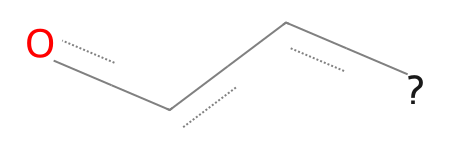

In [6]:
smt

In [7]:
unifac.get_groups("C(CCN(CCCN(CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CN(CCCN(CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN)CCCN(CCCN(CCCN)CCCN)CCCN(CCCN)CCCN", "smiles").subgroups_num

{2: 122, 29: 32, 35: 30}